In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("andrewmvd/covid19-ct-scans")

print("Path to dataset files:", path)
path1=path
import kagglehub

# Download latest version
path = kagglehub.dataset_download("luumsk/medical-segmentation-decathlon-lung")
path2 = path
print("Path to dataset files:", path)

# import kagglehub

# Download latest version
path = kagglehub.dataset_download("rasoulisaeid/lung-cancer-segment")

print("Path to dataset files:", path)
path3=path

Path to dataset files: /kaggle/input/covid19-ct-scans
Path to dataset files: /root/.cache/kagglehub/datasets/luumsk/medical-segmentation-decathlon-lung/versions/7
Path to dataset files: /root/.cache/kagglehub/datasets/rasoulisaeid/lung-cancer-segment/versions/1


In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# x=[]
# y=[]
# z=[]
# for i in range(20):
#   p = '/root/.cache/kagglehub/datasets/andrewmvd/covid19-ct-scans/versions/4/ct_scans/'+os.listdir('/root/.cache/kagglehub/datasets/andrewmvd/covid19-ct-scans/versions/4/ct_scans')[i]
#   if 'coronacases' in p:
#     img = nib.load(p).get_fdata()
#     x.append(img.shape[0])
#     y.append(img.shape[1])
#     z.append(img.shape[2])

# print('Total Images: ',sum(z)+sum(x)+sum(y))

# **Setup the Environment**

In [ ]:
!pip install nilearn niwidgets numpy-stl -q
!pip install open3d k3d -q
!pip3 install ipympl -q
!pip install niwidgets --no-deps

**After succesful installation, restart and clear cell outputs.**
Comment the above lines, hit run all

# **Import all dependencies**

In [ ]:
import os, glob
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import load_model
from tensorflow import keras
import shutil, pathlib, fnmatch
import PIL
from niwidgets import NiftiWidget
import numpy as np
import open3d as o3d
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
from skimage import measure
from stl import mesh
from sklearn.metrics import confusion_matrix
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from scipy.ndimage import binary_closing, binary_dilation, binary_erosion, generate_binary_structure


# **Pre-processing**

In [ ]:
HOUNSFIELD_MIN = -1000
HOUNSFIELD_MAX = 2000
HOUNSFIELD_RANGE = HOUNSFIELD_MAX - HOUNSFIELD_MIN


In [ ]:
# Use the new dataset path
dataInputPath = '/root/.cache/kagglehub/datasets/andrewmvd/covid19-ct-scans/versions/4'
imagePathInput = os.path.join(dataInputPath, 'ct_scans/')
maskPathInput = os.path.join(dataInputPath, 'infection_mask/')

# Define output paths
dataOutputPath = './slices/'  # Local directory to save slices
imageSliceOutput = os.path.join(dataOutputPath, 'img/')
maskSliceOutput = os.path.join(dataOutputPath, 'mask/')

# Create output directories
os.makedirs(imageSliceOutput, exist_ok=True)  # Ensure the directory is created
os.makedirs(maskSliceOutput, exist_ok=True)

# Constants for normalization
HOUNSFIELD_MIN = -1000
HOUNSFIELD_MAX = 2000
HOUNSFIELD_RANGE = HOUNSFIELD_MAX - HOUNSFIELD_MIN

# Slicing flags
SLICE_X = True
SLICE_Y = True
SLICE_Z = True

SLICE_DECIMATE_IDENTIFIER = 3

In [ ]:
# Load image and see max min Hounsfield units
imgPath = os.path.join(imagePathInput, "coronacases_org_002.nii")
#imgPath = os.path.join("coronacases_org_002.nii")
img = nib.load(imgPath).get_fdata()
np.min(img), np.max(img), img.shape, type(img)

(np.float64(-1023.0), np.float64(9567.0), (512, 512, 200), numpy.memmap)

In [ ]:
# Load image mask and see max min Hounsfield units
maskPath = os.path.join(maskPathInput, "coronacases_002.nii")
mask = nib.load(maskPath).get_fdata()
np.min(mask), np.max(mask), mask.shape, type(mask)

(np.float64(0.0), np.float64(1.0), (512, 512, 200), numpy.memmap)

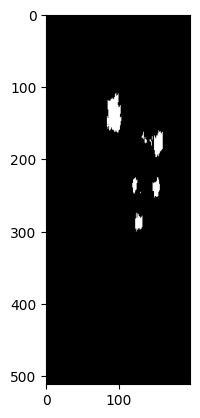

In [ ]:
# Show image slice
imgSlice = mask[150,:,:]
plt.imshow(imgSlice, cmap='gray')
plt.show()

In [ ]:
# Normalize image
HOUNSFIELD_MIN = -1000
HOUNSFIELD_MAX = 2000
HOUNSFIELD_RANGE = HOUNSFIELD_MAX - HOUNSFIELD_MIN

def normalizeImageIntensityRange(img):
    img[img < HOUNSFIELD_MIN] = HOUNSFIELD_MIN
    img[img > HOUNSFIELD_MAX] = HOUNSFIELD_MAX
    return (img - HOUNSFIELD_MIN) / HOUNSFIELD_RANGE

# nImg = normalizeImageIntensityRange(img)
# np.min(nImg), np.max(nImg), nImg.shape, type(nImg)

In [ ]:
# Read image or mask volume
def readImageVolume(imgPath, normalize=False):
    img = nib.load(imgPath).get_fdata()
    if normalize:
        return normalizeImageIntensityRange(img)
    else:
        return img


In [ ]:
# Save volume slice to file
def saveSlice(img, fname, path):
    print("image shape:",img.shape)
    img = np.uint8(img * 255)
    fout = os.path.join(path, f'{fname}.png')
    cv2.imwrite(fout, img)
    print(f'[+] Slice saved: {fout}', end='\r')

# saveSlice(nImg[20,:,:], 'test', imageSliceOutput)
# saveSlice(mask[20,:,:], 'test', maskSliceOutput)

In [ ]:
# Slice image in all directions and save
def sliceAndSaveVolumeImage(vol, fname, path):
    (dimx, dimy, dimz) = vol.shape
    print(dimx, dimy, dimz)
    cnt = 0
    if SLICE_X:
        cnt += dimx
        print('Slicing X: ')
        for i in range(dimx):
            saveSlice(vol[i,:,:], fname+f'-slice{str(i).zfill(SLICE_DECIMATE_IDENTIFIER)}_x', path)

    if SLICE_Y:
        cnt += dimy
        print('Slicing Y: ')
        for i in range(dimy):
            saveSlice(vol[:,i,:], fname+f'-slice{str(i).zfill(SLICE_DECIMATE_IDENTIFIER)}_y', path)

    if SLICE_Z:
        cnt += dimz
        print('Slicing Z: ')
        for i in range(dimz):
            saveSlice(vol[:,:,i], fname+f'-slice{str(i).zfill(SLICE_DECIMATE_IDENTIFIER)}_z', path)
    return cnt

In [ ]:
# # Read and process image volumes
# for index, filename in enumerate(sorted(glob.iglob(imagePathInput+'coronacases*.nii'))):
#     img = readImageVolume(filename, True)
#     # print(filename, img.shape, np.sum(img.shape), np.min(img), np.max(img))
#     numOfSlices = sliceAndSaveVolumeImage(img, 'lungs'+str(index), imageSliceOutput)
#     print(f'\n{filename}, {numOfSlices} slices created \n')

In [ ]:
# # Read and process image mask volumes
# for index, filename in enumerate(sorted(glob.iglob(maskPathInput+'coronacases*.nii'))):
#     img = readImageVolume(filename, False)
#     print(filename, img.shape, np.sum(img.shape), np.min(img), np.max(img))
#     numOfSlices = sliceAndSaveVolumeImage(img, 'lungs'+str(index), maskSliceOutput)
#     print(f'\n{filename}, {numOfSlices} slices created \n')

In [ ]:
# count=0
# for filename in os.listdir("./slices/mask"):
#     count+=1
# count*2

## **CONVERT FROM ZIP TO LIST**



In [ ]:
from glob import glob
# Define paths to slices
imageSliceOutput = './slices/img/'
maskSliceOutput = './slices/mask/'

def get_image_mask_pairs(image_dir, mask_dir):
    # Get sorted lists of image and mask files
    image_files = sorted(glob(os.path.join(image_dir, "*.png")))
    mask_files = sorted(glob(os.path.join(mask_dir, "*.png")))

    print(f"Number of image slices: {len(image_files)}")
    print(f"Number of mask slices: {len(mask_files)}")

    # Match and pair image and mask slices by file name
    pairs = []
    for img_path, mask_path in zip(image_files, mask_files):
        if os.path.basename(img_path) == os.path.basename(mask_path):
            pairs.append((img_path, mask_path))
        else:
            print(f"File name mismatch: {img_path} and {mask_path}")

    return pairs

In [ ]:
# # Generate pairs
# image_mask_pairs = get_image_mask_pairs(imageSliceOutput, maskSliceOutput)

# # Display a few pairs
# print(f"Sample Pairs:")
# for i, pair in enumerate(image_mask_pairs[:5]):
#     print(f"Pair {i + 1}: {pair}")

# **Lung Segmentation using U-net**

Organizing data in appropriate train & test folders

In [ ]:
dataPath = './'
traindataSliceOutput = os.path.join(dataPath, 'training/img/img/')
trainmaskSliceOutput = os.path.join(dataPath, 'training/mask/mask/')
testdataSliceOutput = os.path.join(dataPath, 'test/img/img/')
testmaskSliceOutput = os.path.join(dataPath, 'test/mask/mask/')


In [ ]:
#function to move data from source to destination using string regex
def move_dir(src: str, dst: str, pattern: str = '*'):
    if not os.path.isdir(dst):
        pathlib.Path(dst).mkdir(parents=True, exist_ok=True)
    for f in fnmatch.filter(os.listdir(src), pattern):
        shutil.move(os.path.join(src, f), os.path.join(dst, f))

In [ ]:
os.makedirs(traindataSliceOutput,mode = 0o666)
os.makedirs(trainmaskSliceOutput,mode = 0o666)
os.makedirs(testdataSliceOutput,mode = 0o666)
os.makedirs(testmaskSliceOutput,mode = 0o666)

Uncomment if more test samples are required. Currently using 2 test, 8 train.

In [ ]:
# move_dir(imageSliceOutput,testdataSliceOutput,'lungs6*.png')
# move_dir(imageSliceOutput,testdataSliceOutput,'lungs7*.png')
move_dir(imageSliceOutput,testdataSliceOutput,'lungs8*.png')
move_dir(imageSliceOutput,testdataSliceOutput,'lungs9*.png')
# move_dir(maskSliceOutput,testmaskSliceOutput,'lungs6*.png')
# move_dir(maskSliceOutput,testmaskSliceOutput,'lungs7*.png')
move_dir(maskSliceOutput,testmaskSliceOutput,'lungs8*.png')
move_dir(maskSliceOutput,testmaskSliceOutput,'lungs9*.png')

In [ ]:
#Move the remaining files into training data folder
move_dir(imageSliceOutput,traindataSliceOutput,'*.png')
move_dir(maskSliceOutput,trainmaskSliceOutput,'*.png')

In [ ]:
# Define constants
SEED = 909
BATCH_SIZE_TRAIN = 16
BATCH_SIZE_TEST = 16

IMAGE_HEIGHT = 512
IMAGE_WIDTH = 256
IMG_SIZE = (IMAGE_HEIGHT, IMAGE_WIDTH)

data_dir = './'
data_dir_train = os.path.join(data_dir, 'training')
# The images should be stored under: "data/slices/training/img/img"
data_dir_train_image = os.path.join(data_dir_train, 'img')
# The images should be stored under: "data/slices/training/mask/img"
data_dir_train_mask = os.path.join(data_dir_train, 'mask')

data_dir_test = os.path.join(data_dir, 'test')
# The images should be stored under: "data/slices/test/img/img"
data_dir_test_image = os.path.join(data_dir_test, 'img')
# The images should be stored under: "data/slices/test/mask/img"
data_dir_test_mask = os.path.join(data_dir_test, 'mask')

NUM_TRAIN = len(os.listdir(traindataSliceOutput))
NUM_TEST = len(os.listdir(testdataSliceOutput))

NUM_OF_EPOCHS = 5

Folder structure organization done! Create Data generators for training.

U-net model development

In [ ]:
def unet(n_levels, initial_features=32, n_blocks=2, kernel_size=3, pooling_size=2, in_channels=1, out_channels=1):
    inputs = keras.layers.Input(shape=(IMAGE_HEIGHT, IMAGE_WIDTH, in_channels))
    x = inputs

    convpars = dict(kernel_size=kernel_size, activation='relu', padding='same')

    #downstream
    skips = {}
    for level in range(n_levels):
        for _ in range(n_blocks):
            x = keras.layers.Conv2D(initial_features * 2 ** level, **convpars)(x)
        if level < n_levels - 1:
            skips[level] = x
            x = keras.layers.MaxPool2D(pooling_size)(x)

    # upstream
    for level in reversed(range(n_levels-1)):
        x = keras.layers.Conv2DTranspose(initial_features * 2 ** level, strides=pooling_size, **convpars)(x)
        x = keras.layers.Concatenate()([x, skips[level]])
        for _ in range(n_blocks):
            x = keras.layers.Conv2D(initial_features * 2 ** level, **convpars)(x)

    # output
    activation = 'sigmoid' if out_channels == 1 else 'softmax'
    x = keras.layers.Conv2D(out_channels, kernel_size=1, activation=activation, padding='same')(x)

    return keras.Model(inputs=[inputs], outputs=[x], name=f'UNET-L{n_levels}-F{initial_features}')


In [ ]:
import tensorflow as tf

def dice_coefficient(y_true, y_pred):
    """
    Calculates the Dice coefficient for segmentation masks.

    Args:
        y_true (tf.Tensor): True masks.
        y_pred (tf.Tensor): Predicted masks.

    Returns:
        tf.Tensor: Dice coefficient.
    """
    y_true_f = tf.cast(tf.keras.layers.Flatten()(y_true), tf.float32)
    y_pred_f = tf.cast(tf.keras.layers.Flatten()(y_pred), tf.float32)
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    sum_true_pred = tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f)
    # Handle cases where sum_true_pred is zero to avoid division by zero
    epsilon = tf.keras.backend.epsilon()
    dice = (2. * intersection) / (sum_true_pred + epsilon)
    return dice

In [ ]:
model_covid = load_model('unet_covid.h5', custom_objects={'dice_coefficient': dice_coefficient})
# model_cancer = load_model('unet_cancer.h5', custom_objects={'dice_coefficient': dice_coefficient})

In [ ]:
#Instantiate U-net with 4 levels
model = unet(4)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', dice_coefficient])

def create_segmentation_generator_train(img_path, msk_path, BATCH_SIZE, IMG_SIZE, SEED):
    """
    Creates a data generator for training with data augmentation.

    Args:
        img_path (str): Path to the directory containing training images.
        msk_path (str): Path to the directory containing training masks.
        BATCH_SIZE (int): Batch size.
        IMG_SIZE (tuple): Target size for resizing images (height, width).
        SEED (int): Seed for reproducibility.

    Returns:
        Tuple of image and mask generators.
    """
    data_gen_args = dict(
        rescale=1./255,
        rotation_range=20,  # Example data augmentation
        width_shift_range=0.1,
        height_shift_range=0.1,
        zoom_range=0.1
    )
    datagen = ImageDataGenerator(**data_gen_args)

    img_generator = datagen.flow_from_directory(
        img_path,
        target_size=IMG_SIZE,
        class_mode=None,
        color_mode='grayscale',
        batch_size=BATCH_SIZE,
        seed=SEED
    )
    msk_generator = datagen.flow_from_directory(
        msk_path,
        target_size=IMG_SIZE,
        class_mode=None,
        color_mode='grayscale',
        batch_size=BATCH_SIZE,
        seed=SEED
    )

    return img_generator, msk_generator


def create_segmentation_generator_test(img_path, msk_path, BATCH_SIZE, IMG_SIZE, SEED):
    """
    Creates a data generator for testing without data augmentation.

    Args:
        img_path (str): Path to the directory containing test images.
        msk_path (str): Path to the directory containing test masks.
        BATCH_SIZE (int): Batch size.
        IMG_SIZE (tuple): Target size for resizing images (height, width).
        SEED (int): Seed for reproducibility.

    Returns:
        Tuple of image and mask generators.
    """
    data_gen_args = dict(rescale=1./255) # No augmentation for testing
    datagen = ImageDataGenerator(**data_gen_args)

    img_generator = datagen.flow_from_directory(
        img_path,
        target_size=IMG_SIZE,
        class_mode=None,
        color_mode='grayscale',
        batch_size=BATCH_SIZE,
        seed=SEED
    )
    msk_generator = datagen.flow_from_directory(
        msk_path,
        target_size=IMG_SIZE,
        class_mode=None,
        color_mode='grayscale',
        batch_size=BATCH_SIZE,
        seed=SEED
    )

    return img_generator, msk_generator

# Combined generator function remains the same
def combined_generator(img_generator, mask_generator):
    """
    Combines image and mask generators into a single generator yielding (image, mask) tuples.

    Args:
        img_generator: Keras ImageDataGenerator for images.
        mask_generator: Keras ImageDataGenerator for masks.

    Yields:
        Tuple of (image batch, mask batch).
    """
    while True:
        img_batch = next(img_generator)
        mask_batch = next(mask_generator)
        yield (img_batch, mask_batch)


NameError: name 'IMAGE_HEIGHT' is not defined

In [ ]:
steps_per_epoch = max(1, NUM_TRAIN // BATCH_SIZE_TRAIN)
validation_steps = max(1, NUM_TEST // BATCH_SIZE_TEST)

train_img_dir="/content/training/img"
train_mask_dir="/content/training/mask"
test_img_dir="/content/test/img"
test_mask_dir="/content/test/mask"

train_img_gen, train_mask_gen = create_segmentation_generator_train(train_img_dir, train_mask_dir, BATCH_SIZE_TRAIN, IMG_SIZE, SEED)
test_img_gen, test_mask_gen = create_segmentation_generator_test(test_img_dir, test_mask_dir, BATCH_SIZE_TEST, IMG_SIZE, SEED)

train_generators = combined_generator(train_img_gen, train_mask_gen)
test_generators = combined_generator(test_img_gen, test_mask_gen)

print(f"Updated steps_per_epoch: {steps_per_epoch}")
print(f"Updated validation_steps: {validation_steps}")

Found 10216 images belonging to 1 classes.
Found 10216 images belonging to 1 classes.
Found 2605 images belonging to 1 classes.
Found 2605 images belonging to 1 classes.
Updated steps_per_epoch: 638
Updated validation_steps: 162


In [ ]:
model.fit(
    x=train_generators,
    steps_per_epoch=steps_per_epoch,
    epochs=2,
    validation_data=test_generators,
    validation_steps=validation_steps
)

Epoch 1/2


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(None, 512, 256, 1))
  warnings.warn(msg)


638/638 ━━━━━━━━━━━━━━━━━━━━ 440s 610ms/step - accuracy: 0.9889 - dice_coefficient: 0.1137 - loss: 0.0616 - val_accuracy: 0.9916 - val_dice_coefficient: 0.4512 - val_loss: 0.0193
Epoch 2/2
638/638 ━━━━━━━━━━━━━━━━━━━━ 430s 630ms/step - accuracy: 0.9955 - dice_coefficient: 0.5355 - loss: 0.0110 - val_accuracy: 0.9953 - val_dice_coefficient: 0.5901 - val_loss: 0.0132


In [ ]:
loss, accuracy, dice = model.evaluate(
    test_generators,
    steps=validation_steps
)

print(f"Test Loss: {loss}")
print(f"Test Accuracy: {accuracy}")
print(f"Test Dice Coefficient: {dice}")

162/162 ━━━━━━━━━━━━━━━━━━━━ 39s 156ms/step - accuracy: 0.9954 - dice_coefficient: 0.5841 - loss: 0.0130
Test Loss: 0.013158278539776802
Test Accuracy: 0.9953308701515198
Test Dice Coefficient: 0.5875517129898071


In [ ]:
model.save(f'UNET-LungSegmentation_{IMAGE_HEIGHT}_{IMAGE_WIDTH}.h5')

NameError: name 'model' is not defined

In [ ]:
from warnings import filterwarnings

filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn
import os
import gc
import random
from IPython.display import display
import ipywidgets as widgets
from ipywidgets import interact

from tqdm.auto import tqdm
import torch.nn.functional as F
from torchvision.transforms.v2 import GaussianNoise
# from torchmetrics import JaccardIndex, Precision, Recall, Specificity, F1Score, AUROC
import torch.optim as optim

from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr_skimage
from skimage.metrics import mean_squared_error as mse_skimage
from skimage.metrics import hausdorff_distance
from scipy.ndimage import distance_transform_edt
from tensorflow.keras.preprocessing.image import load_img
from keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import Dataset
from torch.utils.data import DataLoader


import torch
import torch.nn as nn
import torch.nn.functional as F

class UNet1(nn.Module):
    def __init__(self, n_class=1):
        super().__init__()

        self.e11 = nn.Conv2d(1, 64, kernel_size=3, padding=1)
        self.e12 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.e21 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.e22 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.e31 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.e32 = nn.Conv2d(256, 256, kernel_size=3, padding=1)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.e41 = nn.Conv2d(256, 512, kernel_size=3, padding=1)
        self.e42 = nn.Conv2d(512, 512, kernel_size=3, padding=1)
        self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.e51 = nn.Conv2d(512, 1024, kernel_size=3, padding=1)
        self.e52 = nn.Conv2d(1024, 1024, kernel_size=3, padding=1)

        self.upconv1 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.d11 = nn.Conv2d(1024, 512, kernel_size=3, padding=1)
        self.d12 = nn.Conv2d(512, 512, kernel_size=3, padding=1)

        self.upconv2 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.d21 = nn.Conv2d(512, 256, kernel_size=3, padding=1)
        self.d22 = nn.Conv2d(256, 256, kernel_size=3, padding=1)

        self.upconv3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.d31 = nn.Conv2d(256, 128, kernel_size=3, padding=1)
        self.d32 = nn.Conv2d(128, 128, kernel_size=3, padding=1)

        self.upconv4 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.d41 = nn.Conv2d(128, 64, kernel_size=3, padding=1)
        self.d42 = nn.Conv2d(64, 64, kernel_size=3, padding=1)

        self.outconv = nn.Conv2d(64, n_class, kernel_size=1)    # For Segmentation mask
        self.finalconv = nn.Conv2d(64, 1, kernel_size=1)   # For Denoised image

    def forward(self, x):
        x = F.relu(self.e11(x))
        x1 = F.relu(self.e12(x))
        x = self.pool1(x1)

        x = F.relu(self.e21(x))
        x2 = F.relu(self.e22(x))
        x = self.pool2(x2)

        x = F.relu(self.e31(x))
        x3 = F.relu(self.e32(x))
        x = self.pool3(x3)

        x = F.relu(self.e41(x))
        x4 = F.relu(self.e42(x))
        x = self.pool4(x4)

        x = F.relu(self.e51(x))
        x = F.relu(self.e52(x))

        x = self.upconv1(x)
        x = torch.cat([x, x4], dim=1)
        x = F.relu(self.d11(x))
        x = F.relu(self.d12(x))

        x = self.upconv2(x)
        x = torch.cat([x, x3], dim=1)
        x = F.relu(self.d21(x))
        x = F.relu(self.d22(x))

        x = self.upconv3(x)
        x = torch.cat([x, x2], dim=1)
        x = F.relu(self.d31(x))
        x = F.relu(self.d32(x))

        x = self.upconv4(x)
        x = torch.cat([x, x1], dim=1)
        x = F.relu(self.d41(x))
        x = F.relu(self.d42(x))

        out = self.outconv(x)
        return out

model = UNet1().to('cuda')
model.load_state_dict(torch.load('/content/U-Net_best_val_loss.pt'))

FileNotFoundError: [Errno 2] No such file or directory: '/content/U-Net_best_val_loss.pt'

In [ ]:
model_covid = load_model('unet_covid.h5', custom_objects={'dice_coefficient': dice_coefficient})

# **3D mesh generation**

In [ ]:
#normalization. All constants have been defined above
def normalizeImageIntensityRange(img):
    img[img < HOUNSFIELD_MIN] = HOUNSFIELD_MIN
    img[img > HOUNSFIELD_MAX] = HOUNSFIELD_MAX
    return (img - HOUNSFIELD_MIN)/HOUNSFIELD_RANGE

In [ ]:
#Linear interpolation to target width & height
def scaleImg(img, height, width):
    return cv2.resize(img, dsize=(width, height), interpolation=cv2.INTER_LINEAR)

In [ ]:
sliceIndex = 100

IMAGE_HEIGHT = 256
IMAGE_WIDTH = 256

SLICE_X = True
SLICE_Y = True
SLICE_Z = True


In [ ]:
import os
import numpy as np
from torch.utils.data import Dataset, DataLoader
import torch
import torchvision.transforms as transforms
from PIL import Image

class LungSegmentationDataset(Dataset):
    def __init__(self, root_dir):
        self.image_paths = []
        self.mask_paths = []
        patient_dirs = sorted(os.listdir(root_dir))
        for patient in patient_dirs:
            data_dir = os.path.join(root_dir, patient, 'data')
            mask_dir = os.path.join(root_dir, patient, 'masks')

            for file_name in sorted(os.listdir(data_dir)):
                img_path = os.path.join(data_dir, file_name)
                mask_path = os.path.join(mask_dir, file_name)  # same name
                self.image_paths.append(img_path)
                self.mask_paths.append(mask_path)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = np.load(self.image_paths[idx])
        mask = np.load(self.mask_paths[idx])
        image = torch.from_numpy(image).unsqueeze(0).float()
        mask = torch.from_numpy(mask).unsqueeze(0).float()

        return image, mask

train_dataset = LungSegmentationDataset(root_dir=path+'/train')

val_dataset = LungSegmentationDataset(root_dir=path+'/val')

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=4)


In [ ]:
# prompt: input the i to the model_covid, where the i is the torch tensor and the model_covid is the tensorflow

# Ensure the input tensor 'i' has the correct dimensions and data type for the TensorFlow model.
# Assuming model_covid expects input shape (None, IMAGE_HEIGHT, IMAGE_WIDTH, 1)
# And your PyTorch tensor 'i' has shape (batch_size, 1, height, width)

# Transpose the PyTorch tensor to match TensorFlow's channel-last format
i_tf = torch.permute(i, (0, 2, 3, 1)) # Changes shape to (batch_size, height, width, 1)

# Convert the PyTorch tensor to a NumPy array
i_np = i_tf.numpy()

# Resize the input to the expected dimensions (512, 256) and add the channel dimension
# Assuming you want to resize each image in the batch
resized_i_np = np.zeros((i_np.shape[0], 512, 256, 1), dtype=i_np.dtype)
for idx in range(i_np.shape[0]):
    # Remove the channel dimension for resizing
    img_slice = i_np[idx, :, :, 0]
    # Resize to 512x256
    resized_img_slice = cv2.resize(img_slice, (256, 512), interpolation=cv2.INTER_LINEAR)
    # Add the channel dimension back
    resized_i_np[idx, :, :, 0] = resized_img_slice

# Use the TensorFlow model for prediction
prediction = model_covid.predict(resized_i_np)

print("Prediction from model_covid:", prediction)

In [ ]:
IMAGE_HEIGHT = 256
IMAGE_WIDTH = 256

In [ ]:
len(os.listdir(path+'/val/57/data'))

FileNotFoundError: [Errno 2] No such file or directory: '/root/.cache/kagglehub/datasets/luumsk/medical-segmentation-decathlon-lung/versions/7/val/57/data'

In [ ]:
val_data_path = os.path.join(path, 'val', '57', 'data')
val_mask_path = os.path.join(path, 'val', '57', 'masks')
image_files = sorted(glob.glob(os.path.join(val_data_path, "*.npy")))
mask_files = sorted(glob.glob(os.path.join(val_mask_path, "*.npy")))
all_images = [np.load(f) for f in image_files]
all_masks = [np.load(f) for f in mask_files]
image_volume = np.stack(all_images, axis=0) # Stack along a new axis (depth)
mask_volume = np.stack(all_masks, axis=0)   # Stack along a new axis (depth)


In [ ]:
predicted_masks_list = []
for i in tqdm(range(image_volume.shape[0]), desc="Processing slices"):
    img_slice = image_volume[i, :, :]
    if img_slice.shape[0] != IMAGE_HEIGHT or img_slice.shape[1] != IMAGE_WIDTH:
        img_slice = cv2.resize(img_slice, (IMAGE_WIDTH, IMAGE_HEIGHT), interpolation=cv2.INTER_LINEAR)
    img_tensor = torch.from_numpy(img_slice).unsqueeze(0).unsqueeze(0).float().to(device) # Add batch and channel
    output = model(img_tensor)
    predicted_mask_slice = torch.sigmoid(output).squeeze().cpu().numpy() > 0.5 # Remove batch and channel, move to cpu, convert to numpy, threshold
    predicted_masks_list.append(predicted_mask_slice)
predicted_mask_volume = np.stack(predicted_masks_list, axis=0)

In [ ]:
from tqdm import tqdm

In [ ]:
cancer_outputs = predicted_mask_volume

In [ ]:
import numpy as np
predicted_masks_list = []
for i in tqdm(range(image_volume.shape[0]), desc="Processing slices"):
    img_slice = image_volume[i, :, :]
    # Ensure the slice is in a suitable format for cv2.resize
    img_slice = img_slice.astype(np.float32)
    if img_slice.shape[0] != IMAGE_HEIGHT or img_slice.shape[1] != IMAGE_WIDTH:
        img_slice = cv2.resize(img_slice, (IMAGE_WIDTH, IMAGE_HEIGHT), interpolation=cv2.INTER_LINEAR)
    img_input = np.expand_dims(np.expand_dims(img_slice, axis=0), axis=-1)
    img_input = img_input.astype(np.float32)
    predicted_mask_slice = model_covid.predict(img_input)
    predicted_mask_slice = predicted_mask_slice.squeeze() > 0.5
    predicted_masks_list.append(predicted_mask_slice)

predicted_mask_volume = np.stack(predicted_masks_list, axis=0)

Processing data from: /root/.cache/kagglehub/datasets/rasoulisaeid/lung-cancer-segment/versions/1/val/57/data
Processing masks from: /root/.cache/kagglehub/datasets/rasoulisaeid/lung-cancer-segment/versions/1/val/57/masks
Found 274 image files.
Found 274 mask files.
Created 3D image volume with shape: (274, 256, 256)
Created 3D mask volume with shape: (274, 256, 256)
Using device: cuda


Processing slices:   0%|          | 0/274 [00:00<?, ?it/s]

Created 3D predicted mask volume with shape: (274, 256, 256)


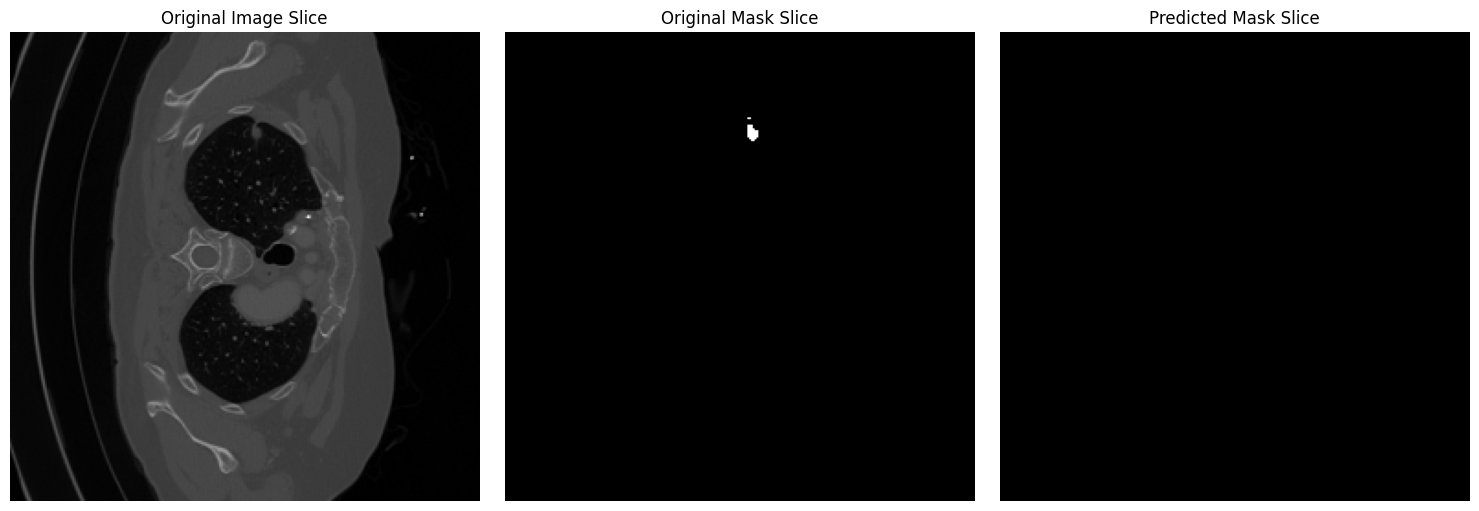

In [ ]:
# prompt: for the path varibale the dataset loader is like this, so now for the a val folder, in 57 folder, we data folder in which there 274 images in .npy files, and then pass throught model and make it as a 3d data, and also make the masks of 274 data in 3d format

# Assuming 'path' is already defined and points to the dataset root
val_data_path = os.path.join(path, 'val', '57', 'data')
val_mask_path = os.path.join(path, 'val', '57', 'masks')

# Check if the directories exist
if not os.path.exists(val_data_path):
    print(f"Validation data path not found: {val_data_path}")
elif not os.path.exists(val_mask_path):
    print(f"Validation mask path not found: {val_mask_path}")
else:
    print(f"Processing data from: {val_data_path}")
    print(f"Processing masks from: {val_mask_path}")

    # Get the list of .npy files
    image_files = sorted(glob.glob(os.path.join(val_data_path, "*.npy")))
    mask_files = sorted(glob.glob(os.path.join(val_mask_path, "*.npy")))

    print(f"Found {len(image_files)} image files.")
    print(f"Found {len(mask_files)} mask files.")

    if len(image_files) != len(mask_files) or len(image_files) == 0:
        print("Mismatch in number of image and mask files or no files found.")
    else:
        # Load all images and masks into lists
        all_images = [np.load(f) for f in image_files]
        all_masks = [np.load(f) for f in mask_files]

        # Stack the 2D arrays into 3D volumes
        # Ensure all slices have the same shape before stacking
        # Assuming all slices from one patient are the same size based on the dataset structure
        try:
            image_volume = np.stack(all_images, axis=0) # Stack along a new axis (depth)
            mask_volume = np.stack(all_masks, axis=0)   # Stack along a new axis (depth)

            print(f"Created 3D image volume with shape: {image_volume.shape}")
            print(f"Created 3D mask volume with shape: {mask_volume.shape}")

            # Example: Pass the image volume through the loaded PyTorch model
            # Need to ensure the model input dimensions match
            # The UNet model expects (batch_size, channels, height, width)
            # Our image_volume is (depth, height, width)
            # We can process slice by slice or try to adapt the model for 3D

            # Option 1: Process slice by slice and then potentially stack the results
            predicted_masks_list = []
            # Move model to evaluation mode and to the correct device
            model.eval()
            device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
            model.to(device)

            print(f"Using device: {device}")

            with torch.no_grad():
                for i in tqdm(range(image_volume.shape[0]), desc="Processing slices"):
                    # Get one slice and add batch and channel dimensions
                    img_slice = image_volume[i, :, :]
                    # Resize if necessary (based on model input size)
                    if img_slice.shape[0] != IMAGE_HEIGHT or img_slice.shape[1] != IMAGE_WIDTH:
                        img_slice = cv2.resize(img_slice, (IMAGE_WIDTH, IMAGE_HEIGHT), interpolation=cv2.INTER_LINEAR)

                    img_tensor = torch.from_numpy(img_slice).unsqueeze(0).unsqueeze(0).float().to(device) # Add batch and channel

                    # Predict
                    output = model(img_tensor)

                    # Get the predicted mask (assuming sigmoid output for binary segmentation)
                    # Apply sigmoid and threshold (e.g., 0.5)
                    predicted_mask_slice = torch.sigmoid(output).squeeze().cpu().numpy() > 0.5 # Remove batch and channel, move to cpu, convert to numpy, threshold

                    # If the output mask needs to be resized back to original slice size before stacking
                    # if predicted_mask_slice.shape[0] != all_images[i].shape[0] or predicted_mask_slice.shape[1] != all_images[i].shape[1]:
                    #     predicted_mask_slice = cv2.resize(predicted_mask_slice.astype(np.uint8), (all_images[i].shape[1], all_images[i].shape[0]), interpolation=cv2.INTER_NEAREST)


                    predicted_masks_list.append(predicted_mask_slice)

            # Stack the predicted masks to form a 3D volume
            predicted_mask_volume = np.stack(predicted_masks_list, axis=0)

            print(f"Created 3D predicted mask volume with shape: {predicted_mask_volume.shape}")

            # Now you have the original image volume, original mask volume, and predicted mask volume in 3D format.
            # You can use these volumes for 3D visualization, evaluation, etc.

            # Example: Simple visualization of a slice from the volumes
            slice_idx_to_show = 130

            plt.figure(figsize=(15, 5))

            plt.subplot(1, 3, 1)
            plt.imshow(image_volume[slice_idx_to_show, :, :], cmap='gray')
            plt.title("Original Image Slice")
            plt.axis('off')

            plt.subplot(1, 3, 2)
            plt.imshow(mask_volume[slice_idx_to_show, :, :], cmap='gray') # Assuming mask is 0 or 1
            plt.title("Original Mask Slice")
            plt.axis('off')

            plt.subplot(1, 3, 3)
            plt.imshow(predicted_mask_volume[slice_idx_to_show, :, :].squeeze(), cmap='gray') # Assuming mask is 0 or 1
            plt.title("Predicted Mask Slice")
            plt.axis('off')

            plt.tight_layout()
            plt.show()

        except ValueError as e:
            print(f"Error stacking images/masks: {e}")
            print("Ensure all input NPY files have the same spatial dimensions.")

In [ ]:
predicted_mask_volume.shape

(274, 256, 256)

Load a sample test case, inference it and visualize

In [ ]:
path

'/root/.cache/kagglehub/datasets/luumsk/medical-segmentation-decathlon-lung/versions/7'

In [ ]:
os.listdir(path1)

['infection_mask',
 'lung_and_infection_mask',
 'lung_mask',
 'ct_scans',
 'metadata.csv']

In [ ]:
targetImagePath = f'{path1}/ct_scans/coronacases_org_010.nii'
targetMaskPath  = f'{path1}/infection_mask/coronacases_010.nii'

imgTargetNii = nib.load(targetImagePath)
imgMaskNii = nib.load(targetMaskPath)
imgTarget = normalizeImageIntensityRange(imgTargetNii.get_fdata())
imgMask = imgMaskNii.get_fdata()


# dataInputPath = '/root/.cache/kagglehub/datasets/andrewmvd/covid19-ct-scans/versions/4'
# # dataInputPath = '/kaggle/input/covid19-ct-scans'
# imagePathInput = os.path.join(dataInputPath, 'ct_scans/')
# maskPathInput = os.path.join(dataInputPath, 'infection_mask/')

# # Specify the specific image and mask file names
# targetImageFile = 'coronacases_org_010.nii'
# targetMaskFile = 'coronacases_010.nii'

# dataInputPath = '/root/.cache/kagglehub/datasets/luumsk/medical-segmentation-decathlon-lung/versions/7'
# imagePathInput = os.path.join(dataInputPath, 'imagesTr/')
# maskPathInput = os.path.join(dataInputPath, 'labelsTr/')

# targetImageFile = 'lung_006.nii'
# targetMaskFile = 'lung_006.nii'
# # Generate full paths for the target image and mask
# targetImagePath = os.path.join(imagePathInput, targetImageFile)
# targetMaskPath = os.path.join(maskPathInput, targetMaskFile)


# Load the NIfTI files
imgTargetNii = nib.load(targetImagePath)
imgMaskNii = nib.load(targetMaskPath)

# Process the loaded data
def normalizeImageIntensityRange(image):
    return (image - image.min()) / (image.max() - image.min())

imgTarget = normalizeImageIntensityRange(imgTargetNii.get_fdata())
imgMask = imgMaskNii.get_fdata()

# Check the shapes or any other information
print(f"Image Shape: {imgTarget.shape}")
print(f"Mask Shape: {imgMask.shape}")


Image Shape: (512, 512, 301)
Mask Shape: (512, 512, 301)


In [ ]:
def predictVolume(inImg, toBin=True):
    (xMax, yMax, zMax) = inImg.shape

    outImgX = np.zeros((xMax, yMax, zMax))
    outImgY = np.zeros((xMax, yMax, zMax))
    outImgZ = np.zeros((xMax, yMax, zMax))

    cnt = 0.0
    # Set model to evaluation mode and move to device
    model.eval()
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)

    with torch.no_grad(): # Disable gradient calculation for inference
      if True:
          cnt += 1.0
          for i in range(xMax):
              # Prepare input for PyTorch model
              img = scaleImg(inImg[i,:,:], IMAGE_HEIGHT, IMAGE_WIDTH)
              img_tensor = torch.from_numpy(img).unsqueeze(0).unsqueeze(0).float().to(device) # Add batch and channel

              # Predict using PyTorch model
              output = model(img_tensor)

              # Process output: apply sigmoid, squeeze, move to cpu, convert to numpy
              tmp = torch.sigmoid(output).squeeze().cpu().numpy()
              outImgX[i,:,:] = scaleImg(tmp, yMax, zMax)

      if True:
          cnt += 1.0
          for i in range(yMax):
              # Prepare input for PyTorch model
              img = scaleImg(inImg[:,i,:], IMAGE_HEIGHT, IMAGE_WIDTH)
              img_tensor = torch.from_numpy(img).unsqueeze(0).unsqueeze(0).float().to(device) # Add batch and channel

              # Predict using PyTorch model
              output = model(img_tensor)

              # Process output: apply sigmoid, squeeze, move to cpu, convert to numpy
              tmp = torch.sigmoid(output).squeeze().cpu().numpy()
              outImgY[:,i,:] = scaleImg(tmp, xMax, zMax)

      if True:
          cnt += 1.0
          for i in range(zMax):
              # Prepare input for PyTorch model
              img = scaleImg(inImg[:,:,i], IMAGE_HEIGHT, IMAGE_WIDTH)
              img_tensor = torch.from_numpy(img).unsqueeze(0).unsqueeze(0).float().to(device) # Add batch and channel

              # Predict using PyTorch model
              output = model(img_tensor)

              # Process output: apply sigmoid, squeeze, move to cpu, convert to numpy
              tmp = torch.sigmoid(output).squeeze().cpu().numpy()
              outImgZ[:,:,i] = scaleImg(tmp, xMax, yMax)

    outImg = (outImgX + outImgY + outImgZ)/cnt
    if(toBin):
        outImg[outImg>0.5] = 1.0
        outImg[outImg<=0.5] = 0.0
    return outImg

In [ ]:
model = model_covid

In [ ]:
predImg = predictVolume(imgTarget)

AttributeError: 'Functional' object has no attribute 'eval'

Visualize annotated mask

##Load and Visualize NIfTI Mask##

In [ ]:

from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from stl import mesh

imgTarget = image_volume.transpose(1,2,0)
imgMask = mask_volume.transpose(1,2,0)
predImg = predicted_mask_volume.transpose(1,2,0)


predImg = predImg

# Generate vertices and faces using marching cubes
vertices, faces, _, _ = measure.marching_cubes(predImg, level=0.5)
ctvertices, ctfaces, _, _ = measure.marching_cubes(imgTarget, level=0.5)
maskvertices, maskfaces, _, _ = measure.marching_cubes(imgMask, level=0.5)

# Optional: Display the number of vertices and faces for debugging
print(f"Inferred Mask: {len(vertices)} vertices, {len(faces)} faces")
print(f"Input Scan: {len(ctvertices)} vertices, {len(ctfaces)} faces")
print(f"Annotated Mask: {len(maskvertices)} vertices, {len(maskfaces)} faces")


Inferred Mask: 580 vertices, 1152 faces
Input Scan: 83486 vertices, 154792 faces
Annotated Mask: 1070 vertices, 2124 faces


In [ ]:
# prompt: calculate the dice score of predImg and imgMask

def calculate_dice_score(predImg, imgMask):
    """
    Calculates the Dice Similarity Coefficient (DSC) between two binary masks.

    Args:
        predImg (np.ndarray): Predicted binary mask.
        imgMask (np.ndarray): Ground truth binary mask.

    Returns:
        float: Dice score.
    """
    # Ensure both inputs are binary (0 or 1)
    predImg_binary = (predImg > 0.5).astype(np.float32)
    imgMask_binary = (imgMask > 0.5).astype(np.float32)

    intersection = np.sum(predImg_binary * imgMask_binary)
    sum_masks = np.sum(predImg_binary) + np.sum(imgMask_binary)

    # Avoid division by zero
    if sum_masks == 0:
        return 1.0  # Or 0.0, depending on how you define Dice for empty masks

    dice = (2. * intersection) / sum_masks
    return dice

# Calculate and print the Dice score
dice_score = calculate_dice_score(mask_volume, predicted_mask_volume)
print(f"Dice Score: {dice_score}")

Dice Score: 0.0


Save all .stl mesh files

In [ ]:
# mm = dataToMesh(vertices, faces)
# mm.save('./Inferenced_lung_010.stl')
# mm = dataToMesh(ctvertices, ctfaces)
# mm.save('./Input_lung_010.stl')
# mm = dataToMesh(maskvertices, maskfaces)
# mm.save('./Mask_lung_010.stl')

# Function to convert vertices and faces to mesh
def dataToMesh(vert, faces):
    stl_mesh = mesh.Mesh(np.zeros(faces.shape[0], dtype=mesh.Mesh.dtype))
    for i, f in enumerate(faces):
        for j in range(3):
            stl_mesh.vectors[i][j] = vert[f[j], :]
    return stl_mesh

# Convert and save all .stl files
output_path = './'  # Define your output directory
inference_mesh = dataToMesh(vertices, faces)
inference_mesh.save(output_path + 'Inferenced_lung.stl')

# input_mesh = dataToMesh(ctvertices, ctfaces)
# input_mesh.save(output_path + 'Input_lung_003.stl')

mask_mesh = dataToMesh(maskvertices, maskfaces)
mask_mesh.save(output_path + 'Mask_lung.stl')

print("STL files saved successfully.")


STL files saved successfully.


# **Metrics**

In [ ]:
def confusion_matrix_gen(y_true,y_pred):
    y_true=y_true.flatten()
    y_pred=y_pred.flatten()
    y_true[y_true>0.5]=1.0
    y_pred[y_pred>0.5]=1.0
    tn, fp, fn, tp=confusion_matrix(y_true, y_pred).ravel()
    return (tn,fp,fn,tp)

def accuracy(TN, FP, FN, TP):
    return (TP+TN)/(TN+FP+FN+TP)

def precision(TN, FP, FN, TP):
    return TP/(TP+FP)

def recall(TN, FP, FN, TP):
    return TP/(TP+FN)

def dsc(TN, FP, FN, TP):
    return (2*TP)/((2*TP)+FP+FN)

def jsi(TN, FP, FN, TP):
    return TP/(TP+FP+FN)

def f1_score(TN, FP, FN, TP):
    precision=TP/(TP+FP)
    recall=TP/(TP+FN)
    return 2*(precision*recall)/(precision+recall)

**CRASHES KERNEL**

In [ ]:
# # Path to dataset
# dataset_path = '/root/.cache/kagglehub/datasets/andrewmvd/covid19-ct-scans/versions/4'

# # Initialize confusion matrix counters
# TN, FP, FN, TP = 0, 0, 0, 0

# # Test set
# testset = ["009", "010"]

# for i in testset:
#     # Correct paths for target images and masks
#     targetImagePath = f'{dataset_path}/ct_scans/coronacases_org_{i}.nii'
#     targetMaskPath = f'{dataset_path}/infection_mask/coronacases_{i}.nii'

#     # Load target image and mask
#     imgTargetNii = nib.load(targetImagePath)
#     imgMaskNii = nib.load(targetMaskPath)

#     # Process target image and mask
#     imgTarget = normalizeImageIntensityRange(imgTargetNii.get_fdata())
#     imgMask = imgMaskNii.get_fdata()

#     # Generate prediction and confusion matrix
#     predImg = predictVolume(imgTarget)
#     tn, fp, fn, tp = confusion_matrix_gen(imgMask, predImg)

#     # Update cumulative counts
#     TN += tn
#     FP += fp
#     FN += fn
#     TP += tp

# # Calculate and print metrics
# print("Accuracy:", accuracy(TN, FP, FN, TP))
# print("Precision:", precision(TN, FP, FN, TP))
# print("Recall:", recall(TN, FP, FN, TP))
# print("DSC:", dsc(TN, FP, FN, TP))
# print("JSI:", jsi(TN, FP, FN, TP))
# print("F1 Score:", f1_score(TN, FP, FN, TP))


# **Point cloud generation**

In [ ]:
# mesh = o3d.io.read_triangle_mesh("./Inferenced_lung_010.stl")
# print("_")
# pointcloud = mesh.sample_points_poisson_disk(100000)
# xyz_load = np.asarray(pointcloud.points,dtype=np.float32)
# print('xyz_load shape', xyz_load.shape)

# Set the correct path to the .stl file
stl_file_path = "/content/Inferenced_lung.stl"  # Adjust path if needed

# Read the .stl file using Open3D
mesh = o3d.io.read_triangle_mesh(stl_file_path)
print("_")

# Sample points using Poisson disk sampling
pointcloud = mesh.sample_points_poisson_disk(100000)

# Convert sampled points to a numpy array
xyz_load = np.asarray(pointcloud.points, dtype=np.float32)
print('xyz_load shape', xyz_load.shape)

# stl_file_path = "/content/Mask_lung_010.stl"  # Adjust path if needed

# # Read the .stl file using Open3D
# mesh = o3d.io.read_triangle_mesh(stl_file_path)
# print("_")

# # Sample points using Poisson disk sampling
# pointcloud = mesh.sample_points_poisson_disk(100000)

# # Convert sampled points to a numpy array
# xyz_load_true = np.asarray(pointcloud.points, dtype=np.float32)
# print('xyz_load shape', xyz_load.shape)

_
xyz_load shape (100000, 3)


In [ ]:
# prompt: wrte the code to plot the predImg and imgMask in 3d

def plot_3d_volume(volume, title):
    """Plots a 3D volume using marching cubes."""
    # Generate vertices and faces using marching cubes
    try:
        verts, faces, _, _ = measure.marching_cubes(volume, level=0.5)
    except ValueError as e:
        print(f"Could not perform marching cubes for {title}: {e}")
        print("This might happen if the volume is empty or constant.")
        return

    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111, projection='3d')

    # Plot the surface
    mesh = Poly3DCollection(verts[faces])
    mesh.set_edgecolor('k')
    ax.add_collection3d(mesh)

    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    ax.set_title(title)

    # Auto scale axes to match the volume size
    ax.set_xlim(0, volume.shape[0])
    ax.set_ylim(0, volume.shape[1])
    ax.set_zlim(0, volume.shape[2])
    plt.savefig(title+'.png')
    print('Image Saved')



In [ ]:
mask_volume.shape

(274, 256, 256)

In [ ]:

# Plot the predicted image volume
plot_3d_volume(predicted_mask_volume, "PredCovid")

Could not perform marching cubes for PredCovid: Surface level must be within volume data range.
This might happen if the volume is empty or constant.


Image Saved


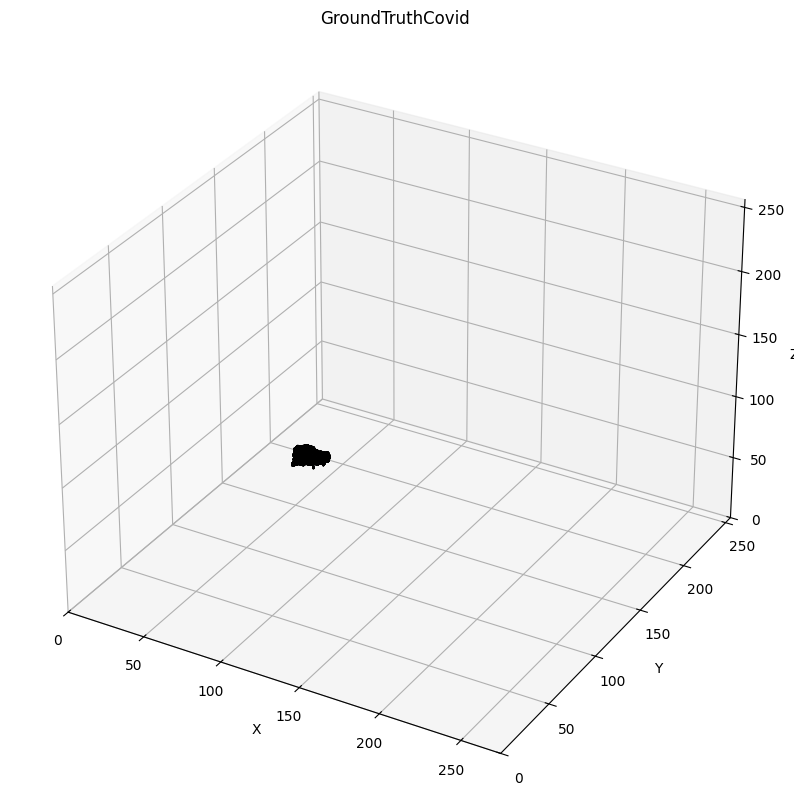

In [ ]:
# Plot the ground truth mask volume
plot_3d_volume(mask_volume, "GroundTruthCovid")


In [ ]:
# import os
# import numpy as np
# import nibabel as nib
# import matplotlib.pyplot as plt
# from skimage import measure
# from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# def extract_mesh(volume, threshold=0.5):
#     """Extracts a mesh using marching cubes from a binary volume."""
#     binary = (volume > threshold).astype(np.uint8)
#     verts, faces, _, _ = measure.marching_cubes(binary, level=0)
#     return verts, faces

# def plot_fp_fn(gt_nii_path, pred_nii_path):
#     # Load volumes
#     gt_vol = gt_nii_path
#     pred_vol = pred_nii_path

#     # Binarize
#     gt_bin = (gt_vol > 0.5).astype(np.uint8)
#     pred_bin = (pred_vol > 0.5).astype(np.uint8)

#     # False Positives: pred=1, gt=0
#     false_positives = np.logical_and(pred_bin == 1, gt_bin == 0).astype(np.uint8)
#     fp_verts, fp_faces = extract_mesh(false_positives)

#     # False Negatives: pred=0, gt=1
#     false_negatives = np.logical_and(pred_bin == 0, gt_bin == 1).astype(np.uint8)
#     fn_verts, fn_faces = extract_mesh(false_negatives)

#     # Create subplots
#     fig = plt.figure(figsize=(16, 8))

#     # Plot False Positives
#     ax1 = fig.add_subplot(1, 2, 1, projection='3d')
#     if len(fp_verts) > 0:
#         fp_mesh = Poly3DCollection(fp_verts[fp_faces], alpha=0.6)
#         fp_mesh.set_facecolor('red')
#         ax1.add_collection3d(fp_mesh)
#         ax1.set_title('False Positives (Predicted Extra)')
#     else:
#         ax1.set_title('No False Positives')

#     # Plot False Negatives
#     ax2 = fig.add_subplot(1, 2, 2, projection='3d')
#     if len(fn_verts) > 0:
#         fn_mesh = Poly3DCollection(fn_verts[fn_faces], alpha=0.6)
#         fn_mesh.set_facecolor('blue')
#         ax2.add_collection3d(fn_mesh)
#         ax2.set_title('False Negatives (Missed Predictions)')
#     else:
#         ax2.set_title('No False Negatives')

#     # Set common axis limits
#     all_verts = np.vstack([fp_verts, fn_verts]) if len(fp_verts) > 0 and len(fn_verts) > 0 else (fp_verts if len(fp_verts) > 0 else fn_verts)
#     if all_verts.size > 0:
#         ax1.set_xlim(0, np.max(all_verts[:, 0]))
#         ax1.set_ylim(0, np.max(all_verts[:, 1]))
#         ax1.set_zlim(0, np.max(all_verts[:, 2]))
#         ax2.set_xlim(0, np.max(all_verts[:, 0]))
#         ax2.set_ylim(0, np.max(all_verts[:, 1]))
#         ax2.set_zlim(0, np.max(all_verts[:, 2]))

#     plt.tight_layout()
#     plt.savefig("False_Positive_vs_Negative.png")
#     plt.show()

# # Usage:
# plot_fp_fn(imgMask, predImg)


In [ ]:

# import os
# import torch
# import numpy as np
# import nibabel as nib
# import cv2
# from tqdm import tqdm
# from torch.nn.functional import softmax

# def preprocess_slice(slice_2d):
#     resized = cv2.resize(slice_2d, (256, 256), interpolation=cv2.INTER_AREA)
#     normalized = resized.astype(np.float32) / 255.0
#     tensor = torch.FloatTensor(normalized).unsqueeze(0).unsqueeze(0)  # [1, 1, H, W]
#     return tensor  # [1, 1, 256, 256]


# import nibabel as nib
# import numpy as np
# from skimage import measure
# import matplotlib.pyplot as plt
# from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# def extract_mesh_from_nii(nii_file, threshold=0.5):
#     nii = nib.load(nii_file)
#     volume = nii.get_fdata()
#     binary = (volume > threshold).astype(np.uint8)
#     verts, faces, _, _ = measure.marching_cubes(binary, level=0)
#     return verts, faces

# def plot_two_meshes(gt_nii_path, pred_nii_path):
#     gt_verts, gt_faces = extract_mesh_from_nii(gt_nii_path)
#     pred_verts, pred_faces = extract_mesh_from_nii(pred_nii_path)

#     fig = plt.figure(figsize=(10, 10))
#     ax = fig.add_subplot(111, projection='3d')

#     # Ground Truth Mesh - Blue
#     gt_mesh = Poly3DCollection(gt_verts[gt_faces], alpha=0.4)
#     gt_mesh.set_facecolor('blue')
#     ax.add_collection3d(gt_mesh)

#     # Predicted Mask Mesh - Red
#     pred_mesh = Poly3DCollection(pred_verts[pred_faces], alpha=0.4)
#     pred_mesh.set_facecolor('red')
#     ax.add_collection3d(pred_mesh)

#     # Set axis limits based on larger volume
#     all_verts = np.vstack((gt_verts, pred_verts))
#     ax.set_xlim(0, np.max(all_verts[:, 0]))
#     ax.set_ylim(0, np.max(all_verts[:, 1]))
#     ax.set_zlim(0, np.max(all_verts[:, 2]))

#     ax.set_title("Ground Truth (Blue) vs Predicted Mask (Red)")
#     plt.tight_layout()
#     plt.savefig('PredvsMask.png')
#     plt.show()


In [ ]:
# plot_two_meshes('/root/.cache/kagglehub/datasets/andrewmvd/covid19-ct-scans/versions/4/infection_mask/coronacases_010.nii', "/content/pred_Mask.nii")

NameError: name 'plot_two_meshes' is not defined

In [ ]:
with open('Inferenced_lung_010_pcd.xyz', 'w') as f:
    for line in xyz_load:
        f.write("{}\t {}\t {}\t".format(str(line[0]),str(line[1]),str(line[2])))
        f.write('\n')

One-time pcd loop generation

In [ ]:
for filename in sorted(glob.iglob("./" + '*.stl')):
    mesh = o3d.io.read_triangle_mesh(filename)
    print("Mesh read complete")
    pointcloud = mesh.sample_points_poisson_disk(100000)
    print("PCD generation complete")
    xyz_load = np.asarray(pointcloud.points,dtype=np.float32)
    print('xyz_load shape', xyz_load.shape)
    with open('{}_pcd.xyz'.format(filename[:-4]), 'w') as f:
        for line in xyz_load:
            f.write("{}\t {}\t {}\t".format(str(line[0]),str(line[1]),str(line[2])))
            f.write('\n')

Mesh read complete
PCD generation complete
xyz_load shape (100000, 3)
Mesh read complete
PCD generation complete
xyz_load shape (100000, 3)


In [ ]:
import trimesh
import numpy as np
import os

def load_and_color_mesh(file_path, color):
    """Load a mesh or convert point cloud to mesh, then color it."""
    obj = trimesh.load(file_path, process=False)

    # Convert PointCloud to Mesh if needed
    if isinstance(obj, trimesh.points.PointCloud):
        print(f"ℹ️ Converting PointCloud to Mesh: {file_path}")
        mesh = obj.convex_hull
    elif isinstance(obj, trimesh.Trimesh):
        mesh = obj
    else:
        raise TypeError(f"Unsupported type: {type(obj)}")

    # Add face colors (RGBA)
    mesh.visual.face_colors = np.tile(color + [255], (len(mesh.faces), 1))
    return mesh


def align_meshes(mesh1, mesh2):
    """Align mesh2 to mesh1 using bounding box normalization (if needed)."""
    # This assumes both meshes are already aligned.
    # If not, you can uncomment and adjust this block:

    bounds1 = mesh1.bounds
    bounds2 = mesh2.bounds
    center_shift = bounds1[0] - bounds2[0]  # shift cancer mesh to match lung origin
    mesh2.apply_translation(center_shift)

    return mesh1, mesh2

def combine_meshes_and_export(mesh1, mesh2, output_file):
    """Combine two meshes/point clouds and export as a single .obj file."""
    combined = trimesh.util.concatenate([mesh1, mesh2])
    combined.export(output_file)
    print(f"✅ Combined .obj saved to: {output_file}")

# === Configuration ===
lung_path = 'maskLung.obj'
cancer_path = 'True.obj'
output_path = 'combined2.obj'

# === Step-by-step execution ===
lung_mesh = load_and_color_mesh(lung_path, color=[128, 128, 128])  # Gray
cancer_mesh = load_and_color_mesh(cancer_path, color=[255, 0, 0])  # Red

# Align if needed
lung_mesh, cancer_mesh = align_meshes(lung_mesh, cancer_mesh)

# Combine and export
combine_meshes_and_export(lung_mesh, cancer_mesh, output_path)

✅ Combined .obj saved to: combined2.obj


In [ ]:
4+4

8

In [ ]:
import trimesh
import numpy as np

def load_and_color_mesh(file_path, color):
    obj = trimesh.load(file_path, process=False)

    # Convert PointCloud to Mesh if needed
    if isinstance(obj, trimesh.points.PointCloud):
        print(f"ℹ️ Converting PointCloud to mesh: {file_path}")
        mesh = obj.convex_hull
    elif isinstance(obj, trimesh.Trimesh):
        mesh = obj
    else:
        raise TypeError(f"Unsupported object type: {type(obj)}")

    # Assign face color
    mesh.visual.face_colors = np.tile(color + [255], (len(mesh.faces), 1))
    return mesh

def scale_and_align(cancer_mesh, lung_mesh):
    """
    Scale and align cancer mesh to fit inside lung mesh.
    """
    lung_bbox = lung_mesh.bounds
    cancer_bbox = cancer_mesh.bounds

    # Compute size of bounding boxes
    lung_size = lung_bbox[1] - lung_bbox[0]
    cancer_size = cancer_bbox[1] - cancer_bbox[0]

    # Compute scale factor
    scale_factor = np.min(lung_size / cancer_size)
    print(f"⚙️ Scaling cancer mesh by factor: {scale_factor:.3f}")

    # Scale cancer mesh
    cancer_mesh.apply_scale(scale_factor)

    # Recompute bounds
    cancer_bbox = cancer_mesh.bounds
    cancer_center = (cancer_bbox[0] + cancer_bbox[1]) / 2
    lung_center = (lung_bbox[0] + lung_bbox[1]) / 2

    # Translate cancer to align centers
    translation = lung_center - cancer_center
    cancer_mesh.apply_translation(translation)

    return cancer_mesh
def scale_and_align(cancer_mesh, lung_mesh, manual_scale=0.2):
    """
    Manually scale down the cancer mesh and align it to the lung mesh center.
    """
    print(f"⚙️ Manually scaling cancer mesh by factor: {manual_scale}")
    cancer_mesh.apply_scale(manual_scale)

    # Align centers
    lung_center = lung_mesh.centroid
    cancer_center = cancer_mesh.centroid
    translation = lung_center - cancer_center
    cancer_mesh.apply_translation(translation)
    return cancer_mesh



def combine_meshes_and_export(mesh1, mesh2, output_file):
    combined = trimesh.util.concatenate([mesh1, mesh2])
    combined.export(output_file)
    print(f"✅ Combined mesh saved to {output_file}")

# === File paths ===
lung_path = 'predLung.obj'
cancer_path = 'Pred (1).obj'
output_path = 'combined3233.obj'

# === Load meshes ===
lung_mesh = load_and_color_mesh(lung_path, color=[128, 128, 128])  # Gray
cancer_mesh = load_and_color_mesh(cancer_path, color=[255, 0, 0])  # Red

# === Normalize cancer mesh to lung ===
cancer_mesh = scale_and_align(cancer_mesh, lung_mesh, manual_scale=2.3)  # try 0.1 if still large

# === Combine and export ===
combine_meshes_and_export(lung_mesh, cancer_mesh, output_path)


⚙️ Manually scaling cancer mesh by factor: 2.3
✅ Combined mesh saved to combined3233.obj


##**3D Voxel Morphological stuff**##

In [ ]:
!pip install trimesh -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 712.0/712.0 kB 18.9 MB/s eta 0:00:00


In [ ]:
import numpy as np
import trimesh
from skimage import morphology
from scipy import ndimage
from sklearn.preprocessing import MinMaxScaler
import os
from datetime import datetime

In [ ]:

class Lung3DMorphology:
    def __init__(self, voxel_size=1.0):
        """
        Initialize the 3D morphological operations class.

        Args:
            voxel_size (float): Size of each voxel in the grid (default: 1.0)
        """
        self.voxel_size = voxel_size
        self.mesh = None
        self.voxels = None

    def load_stl(self, file_path):
        """
        Load an STL file containing 3D lung data.

        Args:
            file_path (str): Path to the STL file

        Returns:
            bool: True if loading successful, False otherwise
        """
        try:
            self.mesh = trimesh.load_mesh(file_path)
            print(f"Successfully loaded STL file: {file_path}")
            return True
        except Exception as e:
            print(f"Error loading STL file: {str(e)}")
            return False

    def load_xyz(self, file_path, delimiter='\t'):
      """
      Load an XYZ file containing 3D point cloud data.

      Args:
          file_path (str): Path to the XYZ file
          delimiter (str): Delimiter used in the XYZ file

      Returns:
          bool: True if loading successful, False otherwise
      """
      try:
          # Load points and ensure there are exactly 3 columns
          points = np.genfromtxt(file_path, delimiter=delimiter, invalid_raise=False)
          if points.ndim != 2 or points.shape[1] != 3:
              raise ValueError("XYZ file must contain exactly 3 columns (x, y, z)")

          # Convert point cloud to mesh using convex hull
          self.mesh = trimesh.Trimesh(vertices=points,
                                      faces=trimesh.convex.convex_hull(points)[1])
          print(f"Successfully loaded XYZ file: {file_path}")
          return True
      except Exception as e:
          print(f"Error loading XYZ file: {str(e)}")
          return False


    def convert_to_voxels(self):
        """
        Convert the loaded mesh to a voxel representation.

        Returns:
            bool: True if conversion successful, False otherwise
        """
        if self.mesh is None:
            print("No mesh loaded. Please load an STL or XYZ file first.")
            return False

        try:
            # Voxelize the mesh
            voxelized = self.mesh.voxelized(pitch=self.voxel_size)
            self.voxels = voxelized.matrix
            print(f"Converted mesh to voxels with shape: {self.voxels.shape}")
            return True
        except Exception as e:
            print(f"Error converting to voxels: {str(e)}")
            return False

    def apply_erosion(self, iterations, structure=None):
      """
      Apply morphological erosion to the voxel representation.

      Args:
          iterations (int): Number of erosion iterations
          structure (ndarray): Structuring element for erosion

      Returns:
          ndarray: Eroded voxel array
      """
      if self.voxels is None:
          print("No voxels available. Please convert mesh to voxels first.")
          return None

      if structure is None:
          structure = morphology.ball(1)

      try:
          eroded = self.voxels.copy()
          for _ in range(iterations):
              eroded = morphology.binary_erosion(eroded, footprint=structure)

          print(f"Applied erosion with {iterations} iterations")
          return eroded
      except Exception as e:
          print(f"Error during erosion: {str(e)}")
          return None

    def apply_dilation(self, iterations, structure=None):
        """
        Apply morphological dilation to the voxel representation.

        Args:
            iterations (int): Number of dilation iterations
            structure (ndarray): Structuring element for dilation

        Returns:
            ndarray: Dilated voxel array
        """
        if self.voxels is None:
            print("No voxels available. Please convert mesh to voxels first.")
            return None

        if structure is None:
            structure = morphology.ball(1)  # Default 3D structuring element

        try:
            dilated = self.voxels.copy()
            for _ in range(iterations):
                dilated = morphology.binary_dilation(dilated, footprint=structure)

            print(f"Applied dilation with {iterations} iterations")
            return dilated
        except Exception as e:
            print(f"Error during dilation: {str(e)}")
            return None


    def voxels_to_mesh(self, voxels):
        """
        Convert voxel representation back to mesh.

        Args:
            voxels (ndarray): Binary voxel array

        Returns:
            trimesh.Trimesh: Resulting mesh
        """
        try:
            from skimage import measure

            # Use marching cubes to convert voxels to mesh
            verts, faces, normals, _ = measure.marching_cubes(voxels)

            # Scale vertices by voxel size
            verts *= self.voxel_size

            # Create mesh
            result_mesh = trimesh.Trimesh(
                vertices=verts,
                faces=faces,
                vertex_normals=normals
            )

            return result_mesh
        except Exception as e:
            print(f"Error converting voxels to mesh: {str(e)}")
            return None

    def save_result(self, mesh, output_path):
        """
        Save the resulting mesh to an STL file.

        Args:
            mesh (trimesh.Trimesh): Mesh to save
            output_path (str): Path to save the STL file

        Returns:
            bool: True if saving successful, False otherwise
        """
        try:
            mesh.export(output_path)
            print(f"Successfully saved result to: {output_path}")
            return True
        except Exception as e:
            print(f"Error saving result: {str(e)}")
            return False

In [ ]:

def main():
    # Example usage
    processor = Lung3DMorphology(voxel_size=1.0)

    # Create timestamp for output files
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

    # Process STL file
    stl_path = "/content/Inferenced_lung.stl"  # Replace with your input file path
    if os.path.exists(stl_path):
        processor.load_stl(stl_path)
        processor.convert_to_voxels()

        # # Apply erosion
        # eroded_voxels = processor.apply_erosion(iterations=2)
        # if eroded_voxels is not None:
        #     eroded_mesh = processor.voxels_to_mesh(eroded_voxels)
        #     processor.save_result(eroded_mesh, f"lung_eroded_{timestamp}.stl")

        # Apply dilation
        dilated_voxels = processor.apply_dilation(iterations=2)
        if dilated_voxels is not None:
            dilated_mesh = processor.voxels_to_mesh(dilated_voxels)
            processor.save_result(dilated_mesh, f"lung_dilated_{timestamp}.stl")

    # Process XYZ file
    # xyz_path = "/content/Inferenced_lung_010_pcd.xyz"  # Replace with your input file path
    # if os.path.exists(xyz_path):
    #     processor.load_xyz(xyz_path)
    #     processor.convert_to_voxels()

    #     # Apply erosion
    #     eroded_voxels = processor.apply_erosion(iterations=3)
    #     if eroded_voxels is not None:
    #         eroded_mesh = processor.voxels_to_mesh(eroded_voxels)
    #         processor.save_result(eroded_mesh, f"lung_xyz_eroded_{timestamp}.stl")

    #     # Apply dilation
    #     dilated_voxels = processor.apply_dilation(iterations=3)
    #     if dilated_voxels is not None:
    #         dilated_mesh = processor.voxels_to_mesh(dilated_voxels)
    #         processor.save_result(dilated_mesh, f"lung_xyz_dilated_{timestamp}.stl")

if __name__ == "__main__":
    main()

Successfully loaded STL file: /content/Inferenced_lung.stl
Converted mesh to voxels with shape: (13, 11, 13)
Applied dilation with 2 iterations
Successfully saved result to: lung_dilated_20250625_104958.stl


##TRYING RBF NOW##

In [ ]:
!pip install open3d -q
!pip install pymeshfix -q
!pip install scipy -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 47.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 96.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.0/105.0 MB 7.3 MB/s eta 0:00:00


In [ ]:
import os
import open3d as o3d
import numpy as np
from scipy.interpolate import Rbf

In [ ]:
def set_mesh_color(mesh, color):
    if not mesh.has_vertices():
        print("Mesh has no vertices to color.")
        return
    colors = [color for _ in range(len(mesh.vertices))]
    mesh.vertex_colors = o3d.utility.Vector3dVector(colors)

gaussian, multiquadrartic or thin-plate

In [ ]:
def apply_rbf_smoothing(pcd):
    points = np.asarray(pcd.points)

    # Extract x, y, z coordinates
    x, y, z = points[:, 0], points[:, 1], points[:, 2]

    # RBF interpolation for smoothing
    rbf_x = Rbf(x, y, z, function='gaussian', smooth=0.1)
    rbf_y = Rbf(y, z, x, function='gaussian', smooth=0.1)
    rbf_z = Rbf(z, x, y, function='gaussian', smooth=0.1)

    # Generate new points
    smoothed_points = np.column_stack((rbf_x(x, y, z), rbf_y(y, z, x), rbf_z(z, x, y)))

    # Update the point cloud with smoothed points
    pcd.points = o3d.utility.Vector3dVector(smoothed_points)
    return pcd



In [ ]:

def process_point_cloud(ply_file, output_mesh_file, color=(0.1, 0.1, 0.7)):
    print(f"Processing: {ply_file}")
    pcd = o3d.io.read_point_cloud(ply_file)

    # Downsample and remove noise
    pcd = pcd.voxel_down_sample(voxel_size=0.05)
    print("Downsampling complete.")
    pcd, ind = pcd.remove_statistical_outlier(nb_neighbors=10, std_ratio=1.0)
    print("Noise removal complete.")

    # Estimate normals
    pcd.estimate_normals(search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=0.05, max_nn=20))
    print("Normal estimation complete.")

    # Poisson reconstruction
    mesh, densities = o3d.geometry.TriangleMesh.create_from_point_cloud_poisson(pcd, depth=6)
    print("Poisson reconstruction complete.")

    if not mesh.has_vertices():
        print(f"No vertices found in the generated mesh for {ply_file}. Skipping.")
        return

    mesh.compute_vertex_normals()
    set_mesh_color(mesh, color)

    o3d.io.write_triangle_mesh(output_mesh_file, mesh, write_vertex_normals=True, write_vertex_colors=True)
    print(f"Processed and saved: {output_mesh_file}")

In [ ]:
def visualize_mesh(mesh_file):
    mesh = o3d.io.read_triangle_mesh(mesh_file)
    mesh.compute_vertex_normals()

    if not mesh.has_vertex_colors():
        print(f"Mesh {mesh_file} has no vertex colors. Visualizing without colors.")

    o3d.visualization.draw_geometries([mesh], mesh_show_back_face=True)

In [ ]:
def compute_properties(mesh_file):
    mesh = o3d.io.read_triangle_mesh(mesh_file)
    mesh.compute_vertex_normals()
    return mesh.get_surface_area()

In [ ]:

# input_xyz_file = "/content/Inferenced_lung_pcd.xyz"
# output_dir = "/content/results"

# # Ensure output directory exists
# os.makedirs(output_dir, exist_ok=True)

# # Define the output mesh file path
# output_mesh_file = os.path.join(output_dir, "Inferenced_lung_mesh.obj")

# # Process the point cloud
# process_point_cloud(input_xyz_file, output_mesh_file, color=(0.4, 0.4, 0.4))

# # Compute and save mesh properties
# surface_area = compute_properties(output_mesh_file)

# # Log the results
# log_file_path = os.path.join(output_dir, "results_log.txt")
# with open(log_file_path, "w") as log_file:
#     log_file.write(f"Processed Mesh: {output_mesh_file}\n")
#     log_file.write(f"Surface Area: {surface_area}\n")

# print(f"Results logged in: {log_file_path}")

# # Visualize the mesh
# visualize_mesh(output_mesh_file)

Processing: /content/Inferenced_lung_pcd.xyz
Downsampling complete.
Noise removal complete.
Normal estimation complete.
Poisson reconstruction complete.
[Open3D WARNING] Write OBJ can not include triangle normals.
Processed and saved: /content/results/Inferenced_lung_mesh.obj
Results logged in: /content/results/results_log.txt
[Open3D WARNING] GLFW Error: Failed to detect any supported platform
[Open3D WARNING] GLFW initialized for headless rendering.
[Open3D WARNING] GLFW Error: OSMesa: Library not found
[Open3D WARNING] Failed to create window
[Open3D WARNING] [DrawGeometries] Failed creating OpenGL window.


uses RBF+Ball-pivot

In [ ]:
# import os
# import open3d as o3d
# import numpy as np
# from scipy.interpolate import RBFInterpolator

# def remove_background(mesh, min_component_size=1000):
#     """ Remove unwanted background surfaces based on connected components. """
#     if not mesh.has_vertices():
#         print("Warning: Mesh has no vertices!")
#         return mesh


#     triangle_clusters, cluster_n_triangles, _ = mesh.cluster_connected_triangles()
#     cluster_n_triangles = np.array(cluster_n_triangles)


#     largest_cluster_idx = np.argmax(cluster_n_triangles)


#     filtered_triangles = [i for i, c in enumerate(triangle_clusters) if c == largest_cluster_idx]

#     if len(filtered_triangles) < min_component_size:
#         print("Warning: The detected component is too small, check the input!")
#         return mesh

#     mesh_filtered = mesh.select_by_index(filtered_triangles, invert=False)

#     return mesh_filtered


# def set_mesh_color(mesh, color):
#     """ Set uniform color for the mesh. """
#     if not mesh.has_vertices():
#         print("Mesh has no vertices to color.")
#         return
#     colors = np.tile(color, (len(mesh.vertices), 1))
#     mesh.vertex_colors = o3d.utility.Vector3dVector(colors)

# def apply_rbf_surface_fitting(pcd):
#     """ Fit an implicit RBF surface to smooth and reconstruct the lung shape. """
#     points = np.asarray(pcd.points)


#     num_samples = min(len(points), 5000)
#     sampled_indices = np.random.choice(len(points), num_samples, replace=False)
#     sampled_points = points[sampled_indices]


#     rbf = RBFInterpolator(sampled_points, np.zeros(len(sampled_points)), kernel='thin_plate_spline')
#     smoothed_points = points + 0.01 * np.expand_dims(rbf(points), axis=1)

#     pcd.points = o3d.utility.Vector3dVector(smoothed_points)
#     return pcd

# def process_point_cloud(input_file, output_mesh_file, color=(0.4, 0.4, 0.4), use_bpa=True):
#     print(f"Processing: {input_file}")
#     pcd = o3d.io.read_point_cloud(input_file)

#     # Reduce point cloud density
#     pcd = pcd.voxel_down_sample(voxel_size=0.1)
#     print("Downsampling complete.")

#     # Remove noise
#     pcd, ind = pcd.remove_statistical_outlier(nb_neighbors=10, std_ratio=1.0)
#     print("Noise removal complete.")

#     # Estimate normals
#     pcd.estimate_normals(search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=0.1, max_nn=30))
#     print("Normal estimation complete.")

#     pcd = apply_rbf_surface_fitting(pcd)
#     print("RBF smoothing applied.")

#     if use_bpa:
#         # Ball Pivoting Algorithm (BPA) for meshing
#         distances = pcd.compute_nearest_neighbor_distance()
#         avg_dist = np.mean(distances)
#         mesh = o3d.geometry.TriangleMesh.create_from_point_cloud_ball_pivoting(
#             pcd, o3d.utility.DoubleVector([avg_dist * 1.5, avg_dist * 3.0])
#         )
#         print("Ball Pivoting reconstruction complete.")
#     else:
#         # Poisson Reconstruction (only if BPA fails)
#         mesh, densities = o3d.geometry.TriangleMesh.create_from_point_cloud_poisson(pcd, depth=5)
#         mesh = remove_background(mesh, density_threshold=0.1)
#         print("Poisson reconstruction complete with background removal.")

#     if not mesh.has_vertices():
#         print(f"No vertices found in the generated mesh for {input_file}. Skipping.")
#         return

#     mesh.compute_vertex_normals()
#     set_mesh_color(mesh, color)

#     o3d.io.write_triangle_mesh(output_mesh_file, mesh, write_vertex_normals=True, write_vertex_colors=True)
#     print(f"Processed and saved: {output_mesh_file}")

# def visualize_mesh(mesh_file):
#     """ Load and visualize the mesh. """
#     mesh = o3d.io.read_triangle_mesh(mesh_file)
#     mesh.compute_vertex_normals()

#     if not mesh.has_vertex_colors():
#         print(f"Mesh {mesh_file} has no vertex colors. Visualizing without colors.")

#     o3d.visualization.draw_geometries([mesh], mesh_show_back_face=True)

# def compute_properties(mesh_file):
#     """ Compute surface area of the mesh. """
#     mesh = o3d.io.read_triangle_mesh(mesh_file)
#     mesh.compute_vertex_normals()
#     return mesh.get_surface_area()

# input_xyz_file = "/content/Mask_lung_pcd.xyz"
# output_dir = "/content/results2"
# os.makedirs(output_dir, exist_ok=True)
# output_mesh_file = os.path.join(output_dir, "Mask_mesh.obj")


# process_point_cloud(input_xyz_file, output_mesh_file, color=(0.4, 0.4, 0.4), use_bpa=True)

# surface_area = compute_properties(output_mesh_file)
# log_file_path = os.path.join(output_dir, "results_log.txt")
# with open(log_file_path, "w") as log_file:
#     log_file.write(f"Processed Mesh: {output_mesh_file}\n")
#     log_file.write(f"Surface Area: {surface_area}\n")

# print(f"Results logged in: {log_file_path}")

# visualize_mesh(output_mesh_file)


In [ ]:
# import os
# import open3d as o3d
# import numpy as np
# from scipy.interpolate import Rbf

# def extract_boundary_points(mesh):
#     edges = mesh.get_non_manifold_edges(allow_boundary_edges=True)
#     if edges is None or len(edges) == 0:
#         print("No boundary edges found.")
#         return None
#     boundary_indices = np.unique(np.concatenate(edges))
#     boundary_vertices = np.asarray(mesh.vertices)[boundary_indices]
#     if len(boundary_vertices) < 5:
#         print("Too few boundary points for RBF interpolation.")
#         return None
#     return boundary_vertices

# def fill_holes_rbf(mesh, num_samples=20000, iterations=3):
#     for i in range(iterations):
#         boundary_points = extract_boundary_points(mesh)
#         if boundary_points is None:
#             break
#         x, y, z = boundary_points[:, 0], boundary_points[:, 1], boundary_points[:, 2]
#         indices = np.random.choice(len(x), min(num_samples, len(x)), replace=False)
#         sx, sy, sz = x[indices], y[indices], z[indices]
#         rbf = Rbf(sx, sy, sz, function='multiquadric', smooth=0.01)
#         grid_x, grid_y = np.meshgrid(np.linspace(min(sx), max(sx), 300), np.linspace(min(sy), max(sy), 300))
#         grid_z = rbf(grid_x, grid_y)
#         new_points = np.vstack((grid_x.flatten(), grid_y.flatten(), grid_z.flatten())).T
#         new_pcd = o3d.geometry.PointCloud()
#         new_pcd.points = o3d.utility.Vector3dVector(new_points)
#         poisson_mesh = o3d.geometry.TriangleMesh.create_from_point_cloud_poisson(new_pcd, depth=12)[0]
#         poisson_mesh = poisson_mesh.filter_smooth_taubin(number_of_iterations=20)
#         poisson_mesh.compute_vertex_normals()
#         mesh += poisson_mesh
#     return mesh

# def process_point_cloud(input_file, output_mesh_file):
#     print(f"Processing: {input_file}")
#     pcd = o3d.io.read_point_cloud(input_file)
#     pcd = pcd.voxel_down_sample(voxel_size=0.15)
#     pcd.estimate_normals(search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=1.0, max_nn=150))
#     bpa_mesh = o3d.geometry.TriangleMesh.create_from_point_cloud_ball_pivoting(
#         pcd, o3d.utility.DoubleVector([0.5, 0.9, 1.3]))
#     bpa_mesh = bpa_mesh.filter_smooth_taubin(number_of_iterations=10)
#     bpa_mesh.compute_vertex_normals()
#     mesh = fill_holes_rbf(bpa_mesh, num_samples=20000, iterations=3)
#     o3d.io.write_triangle_mesh(output_mesh_file, mesh)
#     print(f"Processed and saved: {output_mesh_file}")

# input_xyz_file = "/content/Mask_lung_pcd.xyz"
# output_dir = "/content/results2"
# os.makedirs(output_dir, exist_ok=True)
# output_mesh_file = os.path.join(output_dir, "Mask_2.obj")
# process_point_cloud(input_xyz_file, output_mesh_file)







# # import os
# # import open3d as o3d
# # import numpy as np
# # from scipy.interpolate import Rbf

# # def extract_boundary_points(mesh):
# #     edges = mesh.get_non_manifold_edges(allow_boundary_edges=True)
# #     if edges is None or len(edges) == 0:
# #         print("No boundary edges found.")
# #         return None

# #     boundary_indices = np.unique(np.concatenate(edges))
# #     boundary_vertices = np.asarray(mesh.vertices)[boundary_indices]

# #     if len(boundary_vertices) < 5:
# #         print("Too few boundary points for RBF interpolation.")
# #         return None

# #     return boundary_vertices

# # def fill_holes_rbf(mesh, num_samples=5000):
# #     boundary_points = extract_boundary_points(mesh)
# #     if boundary_points is None:
# #         return mesh

# #     x, y, z = boundary_points[:, 0], boundary_points[:, 1], boundary_points[:, 2]

# #     indices = np.random.choice(len(x), min(num_samples, len(x)), replace=False)
# #     sx, sy, sz = x[indices], y[indices], z[indices]

# #     rbf = Rbf(sx, sy, sz, function='multiquadric', smooth=0.1)
# #     grid_x, grid_y = np.meshgrid(np.linspace(min(sx), max(sx), 100), np.linspace(min(sy), max(sy), 100))
# #     grid_z = rbf(grid_x, grid_y)

# #     new_points = np.vstack((grid_x.flatten(), grid_y.flatten(), grid_z.flatten())).T
# #     new_pcd = o3d.geometry.PointCloud()
# #     new_pcd.points = o3d.utility.Vector3dVector(new_points)

# #     poisson_mesh = o3d.geometry.TriangleMesh.create_from_point_cloud_poisson(new_pcd, depth=8)[0]
# #     poisson_mesh.compute_vertex_normals()
# #     return poisson_mesh

# # def process_point_cloud(input_file, output_mesh_file):
# #     print(f"Processing: {input_file}")
# #     pcd = o3d.io.read_point_cloud(input_file)

# #     pcd = pcd.voxel_down_sample(voxel_size=0.3)
# #     pcd.estimate_normals(search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=1.0, max_nn=50))

# #     bpa_mesh = o3d.geometry.TriangleMesh.create_from_point_cloud_ball_pivoting(
# #         pcd, o3d.utility.DoubleVector([0.8, 1.2, 1.6]))

# #     bpa_mesh.compute_vertex_normals()
# #     mesh = fill_holes_rbf(bpa_mesh)

# #     o3d.io.write_triangle_mesh(output_mesh_file, mesh)
# #     print(f"Processed and saved: {output_mesh_file}")

# # input_xyz_file = "/content/Inferenced_lung_010_pcd.xyz"
# # output_dir = "/content/results"
# # os.makedirs(output_dir, exist_ok=True)
# # output_mesh_file = os.path.join(output_dir, "Inferenced_lung_010_mesh.obj")
# # process_point_cloud(input_xyz_file, output_mesh_file)


Processing: /content/Mask_lung_pcd.xyz
No boundary edges found.
[Open3D WARNING] Write OBJ can not include triangle normals.
Processed and saved: /content/results2/Mask_2.obj


##**RANDOM ATTEMPT AT COLOURING**##

In [ ]:
import numpy as np
import nibabel as nib
import open3d as o3d

ct = nib.load('/kaggle/input/covid19-ct-scans/ct_scans/coronacases_org_001.nii').get_fdata()
mask = nib.load('/kaggle/input/covid19-ct-scans/infection_mask/coronacases_001.nii').get_fdata()
lung_mask = mask > 0


In [ ]:
import open3d as o3d


In [ ]:
import numpy as np
import nibabel as nib
import open3d as o3d
import os # Import the os module
all_hu=[]
lung_mask = imgMask>0 #imgMask
ct = imgTarget

lung_indices = np.argwhere(lung_mask)
zmin, ymin, xmin = lung_indices.min(axis=0)
zmax, ymax, xmax = lung_indices.max(axis=0)

print(f"Lung bbox: Z({zmin}-{zmax}), Y({ymin}-{ymax}), X({xmin}-{xmax})")

lung_bbox_min = np.array([xmin, ymin, zmin])
lung_bbox_max = np.array([xmax, ymax, zmax])

stl_file_path = '/content/Mask_lung.stl' #/content/Mask_lung.stl, Inferenced_lung

# Check if the file exists before attempting to load
if not os.path.exists(stl_file_path):
    print(f"Error: STL file not found at {stl_file_path}")
else:
    mesh = o3d.io.read_triangle_mesh(stl_file_path)
    vertices = np.asarray(mesh.vertices)

    if vertices.shape[0] == 0:
        print(f"Error: No vertices loaded from {stl_file_path}")
    else:
        vmin = vertices.min(axis=0)
        vmax = vertices.max(axis=0)
        vertices_normalized = (vertices - vmin) / (vmax - vmin)


        lung_bbox_size = lung_bbox_max - lung_bbox_min
        vertices_voxel = vertices_normalized * lung_bbox_size[::-1] + lung_bbox_min[::-1]
        ct_shape = imgTarget.shape
        vertices_voxel = np.clip(vertices_voxel, 0, np.array(ct_shape[::-1]) - 1).astype(int)


        colors = []

        for idx in range(vertices_voxel.shape[0]):
            z, y, x = vertices_voxel[idx]

            if not (0 <= z < ct_shape[0] and 0 <= y < ct_shape[1] and 0 <= x < ct_shape[2]):
                colors.append([0.5, 0.5, 0.5])
                continue

            if lung_mask[z, y, x] == 0:
                colors.append([0.5, 0.5, 0.5])
                continue

            hu = ct[z, y, x]
            all_hu.append(hu)
            # New thresholds
            if hu < 0.021:
                colors.append([0, 1, 0])  # Green (healthy)
            elif 0.021 <= hu <= 0.059:
                colors.append([1, 1, 0])  # Yellow (moderate infection)
            else:
                colors.append([1, 0, 0])  # Red (severe infection)


        colors = np.array(colors)
        mesh.vertex_colors = o3d.utility.Vector3dVector(colors)


        o3d.io.write_triangle_mesh('True.obj', mesh)

        print("Done making the mesh")

Lung bbox: Z(47-61), Y(129-140), X(115-133)
Done making the mesh


In [ ]:
imgTarget.shape

(256, 256, 274)

(array([[240.,   4.,   4., ...,   0.,   0.,   0.],
        [241.,   4.,   3., ...,   0.,   0.,   0.],
        [240.,   5.,   3., ...,   0.,   0.,   0.],
        ...,
        [256.,   0.,   0., ...,   0.,   0.,   0.],
        [256.,   0.,   0., ...,   0.,   0.,   0.],
        [256.,   0.,   0., ...,   0.,   0.,   0.]]),
 array([0.        , 0.05804443, 0.11608887, 0.17407227, 0.23217773,
        0.2902832 , 0.34814453, 0.40625   , 0.46435547, 0.52246094,
        0.58056641]),
 <a list of 256 BarContainer objects>)

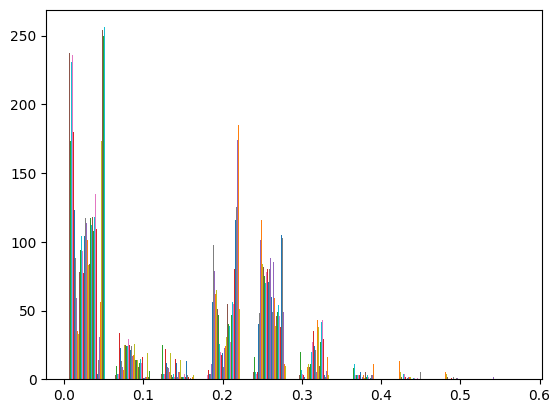

In [ ]:
nikhil = imgTarget[:,:,128][imgMask[:,:,128]]

In [ ]:
low_thresh = np.percentile(hu_lung, 10)   # bottom 10% → healthy
mid_thresh = np.percentile(hu_lung, 60)   # mid 60% → moderate
print(f"10th percentile: {low_thresh}, 60th percentile: {mid_thresh}")


(array([ 18.,  91.,  73.,  60., 121.,  46.,  82.,  84., 209., 245.]),
 array([0.03494263, 0.05841064, 0.08190918, 0.10534668, 0.12878418,
        0.15222168, 0.17578125, 0.19921875, 0.22265625, 0.24609375,
        0.26953125]),
 <BarContainer object of 10 artists>)

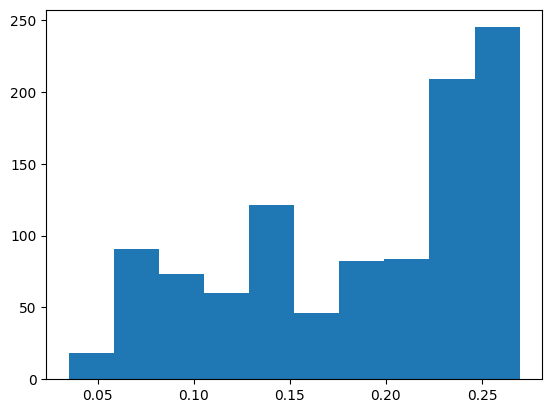

In [ ]:
plt.hist(all_hu)

In [ ]:
# Save mesh as .ply (which supports vertex colors better for web)
mesh = o3d.io.read_triangle_mesh('/content/Inferenced_lung.stl')
o3d.io.write_triangle_mesh("colored_lung_attempt.ply", mesh)

# Load with Plotly (approximate)
import open3d as o3d
import numpy as np
from matplotlib import pyplot as plt
import plotly.graph_objects as go

mesh = o3d.io.read_triangle_mesh("colored_lung_attempt.ply")
vertices = np.asarray(mesh.vertices)
triangles = np.asarray(mesh.triangles)
colors = np.asarray(mesh.vertex_colors)

fig = go.Figure(
    data=[
        go.Mesh3d(
            x=vertices[:, 0],
            y=vertices[:, 1],
            z=vertices[:, 2],
            i=triangles[:, 0],
            j=triangles[:, 1],
            k=triangles[:, 2],
            vertexcolor=colors,
            opacity=1.0
        )
    ]
)
fig.update_layout(scene=dict(aspectmode="data"))
fig.show()
